# Bank Customer Churn Predict Using Machine Learning
### Complete End-to-End Data Mining Project
#### This notebook includes:

1) Data Loading
2) Exploratory Data Analysis (EDA)
3) Descriptive Statistics
4) Inferential Statistics
5) Data Preprocessing
6) Feature Scaling
7) Multiple ML Models
8) Model Evaluation
9) Model Comparison

## Dataset:
   
     Bank Customer Churn Prediction

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns

In [23]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [24]:
db = pd.read_csv("Bank Customer Churn Prediction.csv")

In [25]:
db.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Initial Data Exploration

| Column            | Description                                                                          |
|--------------------------|-------------------------------------------------------------------------------|
| Customer ID              | Unique identifier assigned to each customer (not used for modeling)           |
| Credit Score             | Credit score of the customer indicating financial reliability                 |
| Country                  | Country where the customer is located (e.g., France, Germany, Spain)          |
| Gender                   | Gender of the individual                                                      | 
| Age                      | Age of the individua                                                          |
| Tenure                   | Number of years the customer has been with the bank                           |
| Balance                  | Total account balance of the customer                                         |
| Products Number          | Number of bank products the customer is using                                 |
| Cresdit Card             | Indicates whether the customer has a credit card (1 = Yes, 0 = No)            |
| Active Member            | Indicates whether the customer is an active member (1 = Active, 0 = Inactive) |
| Estimated Salary         | Estimated salary of the customer                                              |
| Churn                    | Target variable: 1 = customer left the bank, 0 = customer stayed              |

In [26]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [27]:
db.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [28]:
db['country'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [29]:
db['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [30]:
db['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [31]:
db.duplicated().sum()

np.int64(0)

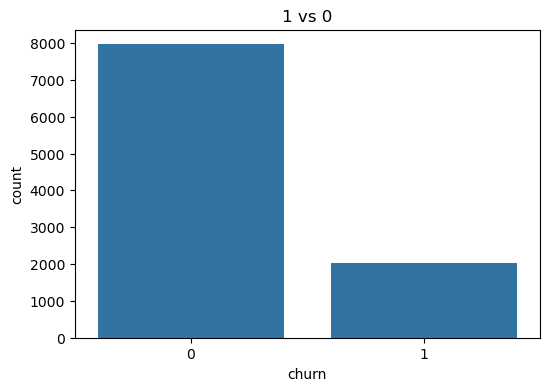

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=db)
plt.title('1 vs 0')
plt.show()

<Axes: >

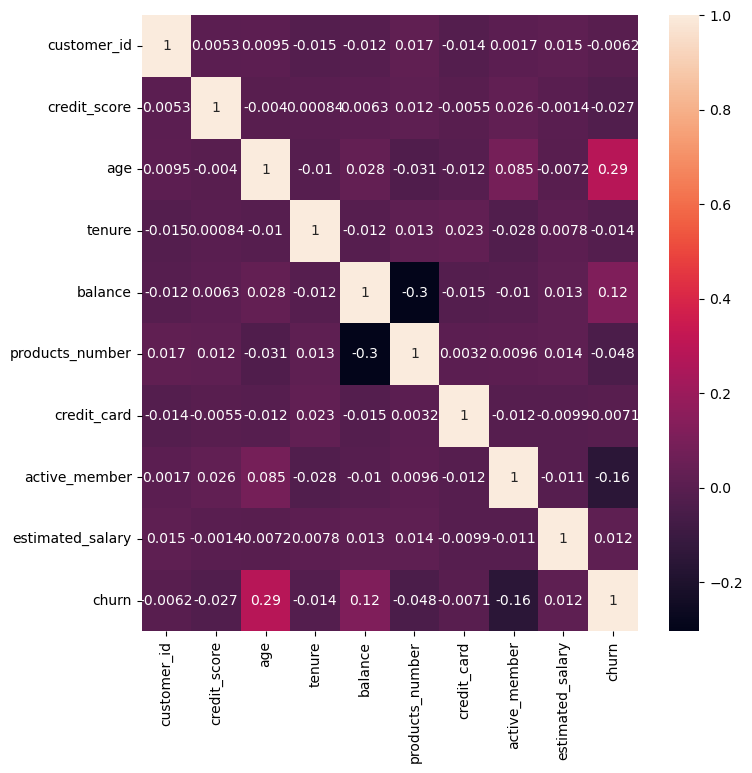

In [33]:
plt.figure(figsize=(8,8))
corr = db.corr(numeric_only = True)
sns.heatmap(corr , annot = True)

In [34]:
db.drop("customer_id" , axis = 1 , inplace = True)

In [35]:
x = db.drop('churn' , axis = 1)
y = db.churn

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.25 , random_state = 43)

In [38]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [39]:
num_cols = X_train.select_dtypes('number')
cat_cols = X_train.select_dtypes('object')

In [40]:
num_pipeline = Pipeline([
               ("Imputer" , SimpleImputer(strategy = 'median')),
               ("Scaler"  , StandardScaler())
                        ])

cat_pipeline = Pipeline([
               ("Imputer" , SimpleImputer(strategy = 'most_frequent')),
               ("Encode"  , OneHotEncoder(drop = 'first' , handle_unknown = 'ignore' , sparse_output = False))
                        ])

In [41]:
preprocessor = ColumnTransformer(
               transformers = [
                             ("num" , num_pipeline , num_cols.columns),
                             ("cat" , cat_pipeline , cat_cols.columns)
                             ]
                                )

# LinearRegression

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
model_lr = LogisticRegression()

In [44]:
model_pipeline_lr  = Pipeline([
                 ("Preprocessor" , preprocessor),
                 ("Model"        , model_lr)
                           ])

In [45]:
model_pipeline_lr.fit(X_train , y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['country', 'gender'], dtype='object'))])),
                ('Model', LogisticRegression())])

In [46]:
y_pred_lr = model_pipeline_lr.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix 

In [48]:
accuracy_score(y_test , y_pred_lr)

0.8112

In [49]:
confusion_matrix(y_test , y_pred_lr)

array([[1920,   62],
       [ 410,  108]])

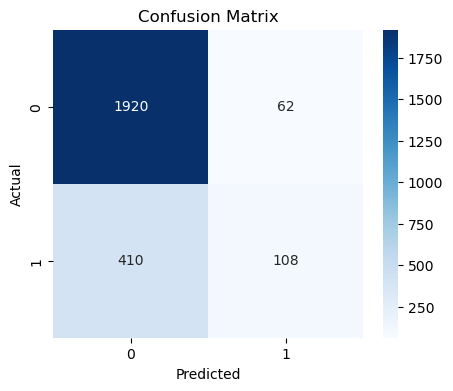

In [50]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [51]:
print(classification_report(y_test , y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1982
           1       0.64      0.21      0.31       518

    accuracy                           0.81      2500
   macro avg       0.73      0.59      0.60      2500
weighted avg       0.78      0.81      0.77      2500



# KN-Neighbour Classifier

In [52]:
from sklearn.neighbors import KNeighborsClassifier

In [54]:
from sklearn.model_selection import GridSearchCV

In [97]:
param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=11)



In [98]:
# model_kn = KNeighborsClassifier(n_neighbors = 9)

In [99]:
model_pipeline_kn  = Pipeline([
                 ("Preprocessor" , preprocessor),
                 ("Model"        , grid)
                           ])

In [100]:
model_pipeline_kn.fit(X_train , y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['country', 'gender'], dtype='object'))])),
                ('Model',
                 GridSearchCV(cv=11, estimator=KNeighborsClassifier(),
                              param_grid={'n_neighbors': [3, 5, 7, 9, 11],
                                          'weights': ['uniform',
                                                      'distance']}))])

In [101]:
y_pred_kn = model_pipeline_kn.predict(X_test)

In [102]:
accuracy_score(y_test , y_pred_kn)

0.8484

In [103]:
confusion_matrix(y_test , y_pred_kn)

array([[1922,   60],
       [ 319,  199]])

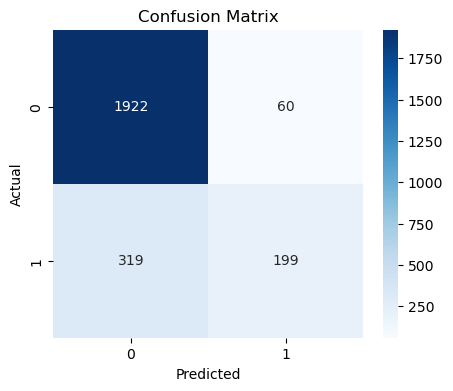

In [104]:
cm = confusion_matrix(y_test, y_pred_kn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [105]:
print(classification_report(y_test , y_pred_kn))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1982
           1       0.77      0.38      0.51       518

    accuracy                           0.85      2500
   macro avg       0.81      0.68      0.71      2500
weighted avg       0.84      0.85      0.83      2500



# Dcision Tree classifier

In [106]:
from sklearn.tree import DecisionTreeClassifier

In [129]:
param_grid2 = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid2 = GridSearchCV(DecisionTreeClassifier(random_state = 42), param_grid2, cv=3)

In [130]:
# model_dt = DecisionTreeClassifier(max_depth = 7 , random_state = 42)

In [131]:
model_pipeline_dt = Pipeline([
                   ("Preprocessor" , preprocessor),
                   ("Model"        , grid2 )
                             ])

In [132]:
model_pipeline_dt.fit(X_train , y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy...frequent')),
                                                                  ('Encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['country', 'gender'], dtype='object'))])),
                ('Model',
                 GridSearchCV(cv=3,
                              estimator=DecisionTreeClassifier(random_state=42),
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [3, 5, 10, None],
                                          'min_samples_leaf': [1, 2, 4],
                                          'min_samples_split': [2, 5, 10]}))])

In [133]:
y_pred_dt = model_pipeline_dt.predict(X_test)

In [134]:
accuracy_score(y_test , y_pred_dt)

0.8528

In [135]:
confusion_matrix(y_test , y_pred_dt)

array([[1879,  103],
       [ 265,  253]])

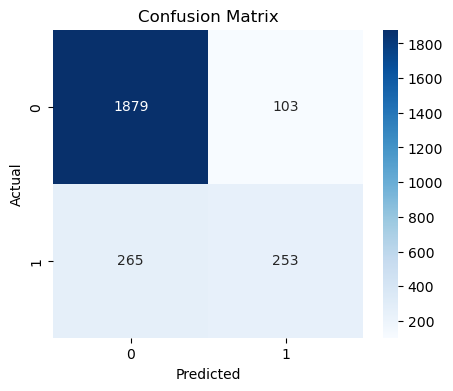

In [136]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [137]:
print(classification_report(y_test , y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1982
           1       0.71      0.49      0.58       518

    accuracy                           0.85      2500
   macro avg       0.79      0.72      0.74      2500
weighted avg       0.84      0.85      0.84      2500



# SVC Modle

In [138]:
from sklearn.svm import SVC

In [139]:
param_grid3 = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid3 = GridSearchCV(SVC(), param_grid3, cv=5)

In [140]:
# model_svc = SVC(C=7.0, kernel='rbf')

In [141]:
model_pipeline_svc = Pipeline([
                    ("Preprocessor" , preprocessor),
                    ("model"        , grid3)
                              ])

In [142]:
model_pipeline_svc.fit(X_train , y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['credit_score', 'age', 'tenure', 'balance', 'products_number',
       'credit_card', 'active_member', 'estimated_salary'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['country', 'gender'], dtype='object'))])),
                ('model',
                 GridSearchCV(cv=5, estimator=SVC(),
                              param_grid={'C': [0.1, 1, 10],
                                          'kernel': ['linear', 'rbf']}))])

In [143]:
y_pred_svc = model_pipeline_svc.predict(X_test)

In [144]:
accuracy_score(y_test , y_pred_svc)

0.854

In [145]:
confusion_matrix(y_test , y_pred_svc)

array([[1932,   50],
       [ 315,  203]])

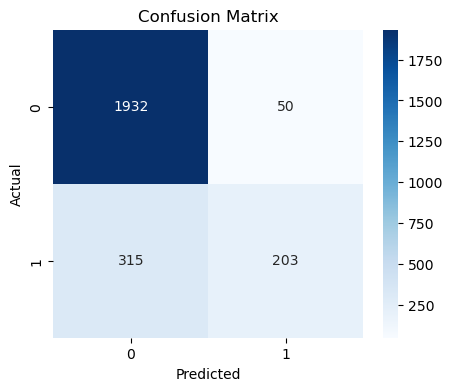

In [146]:
cm = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [147]:
print(classification_report(y_test , y_pred_svc))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1982
           1       0.80      0.39      0.53       518

    accuracy                           0.85      2500
   macro avg       0.83      0.68      0.72      2500
weighted avg       0.85      0.85      0.83      2500



# ANN Model

In [148]:
cat_cols = x.select_dtypes(include=['object']).columns
num_cols = x.select_dtypes(include=['int64', 'float64']).columns

In [149]:
encoder = OneHotEncoder(drop = 'first' , handle_unknown = 'ignore' , sparse_output = False)

In [150]:
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat  = encoder.transform(X_test[cat_cols])

In [151]:
scaler = StandardScaler()

In [152]:
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num  = scaler.transform(X_test[num_cols]) 

In [153]:
X_train_final = np.hstack((X_train_cat, X_train_num))

In [154]:
X_test_final = np.hstack((X_test_cat, X_test_num))

In [155]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras import layers , activations

In [156]:
model_ann = Sequential([
        Dense(64 , activation = 'relu' , input_dim = X_train_final.shape[1]), Dropout(0.3),
        Dense(32  , activation = 'relu'), Dropout(0.3),
        Dense(16  , activation = 'relu'), Dropout(0.2),
        Dense(1  , activation = 'sigmoid')
])

In [157]:
model_ann.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [170]:
history = model_ann.fit(X_train_final , y_train , epochs = 50 , batch_size = 10 , validation_split = 0.20 , verbose = 1)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8663 - loss: 0.3198 - val_accuracy: 0.8687 - val_loss: 0.3551
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8682 - loss: 0.3223 - val_accuracy: 0.8560 - val_loss: 0.3603
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8607 - loss: 0.3229 - val_accuracy: 0.8647 - val_loss: 0.3542
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8695 - loss: 0.3242 - val_accuracy: 0.8587 - val_loss: 0.3523
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8638 - loss: 0.3212 - val_accuracy: 0.8600 - val_loss: 0.3575
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8663 - loss: 0.3230 - val_accuracy: 0.8580 - val_loss: 0.3542
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8670 - loss: 0.3192 - val_accuracy: 0.8593 - val_loss: 0.3556
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8683 - loss: 0.3284 - val_accuracy: 0.

In [171]:
loss , acc = model_ann.evaluate(X_test_final , y_test , verbose = 0)

In [172]:
print(loss)
print(acc)

0.3564237058162689
0.8575999736785889


In [173]:
from sklearn.metrics import precision_score, recall_score

In [174]:
y_pred_ann = (model_ann.predict(X_test_final) > 0.3).astype(int)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [175]:
accuracy_score(y_test , y_pred_ann)

0.8168

In [176]:
precision_score(y_test , y_pred_ann)

0.5458715596330275

In [177]:
recall_score(y_test , y_pred_ann)

0.6891891891891891

In [178]:
print(classification_report(y_test , y_pred_ann))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1982
           1       0.55      0.69      0.61       518

    accuracy                           0.82      2500
   macro avg       0.73      0.77      0.74      2500
weighted avg       0.84      0.82      0.82      2500



In [179]:
print(f"Accuracy        : {accuracy_score(y_test , y_pred_ann)}")
print(f"Precision       : {precision_score(y_test , y_pred_ann)}")
print(f"Recall          : {recall_score(y_test , y_pred_ann)}")
print(f"Classification  : {classification_report(y_test , y_pred_ann)}")

Accuracy        : 0.8168
Precision       : 0.5458715596330275
Recall          : 0.6891891891891891
Classification  :               precision    recall  f1-score   support

           0       0.91      0.85      0.88      1982
           1       0.55      0.69      0.61       518

    accuracy                           0.82      2500
   macro avg       0.73      0.77      0.74      2500
weighted avg       0.84      0.82      0.82      2500



# Models Accuracy Comparision

In [180]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVC",
        "ANN"
    ],

    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_kn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_ann)
    ]
})

print(results)

                 Model  Test Accuracy
0  Logistic Regression         0.8112
1                  KNN         0.8484
2        Decision Tree         0.8528
3                  SVC         0.8540
4                  ANN         0.8168


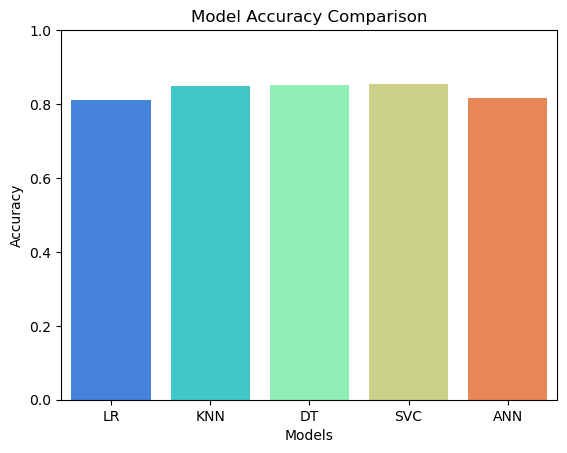

In [181]:
models = ['LR', 'KNN', 'DT', 'SVC', 'ANN']

scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_kn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_svc),
    accuracy_score(y_test, y_pred_ann)
]

sns.barplot(x=models, y=scores, palette='rainbow')

plt.ylim(0, 1)   # safe full range
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Accuracy Comparison")

plt.show()

In [183]:
import pickle

In [185]:
with open("model.pkl_svc", "wb") as f:
    pickle.dump(model_pipeline_svc, f)